# Composer Final Training — Octuple edition

Trains `ComposerOctuple` on an **Octuple**-tokenized dataset produced by `build-octuple-dataset.ipynb`.

This is not a path swap from the REMI notebook. Octuple is a multi-vocabulary tokenization — one step per *note*, eight parallel ids per step — so the model, the loss, the data pipeline and the sampler all change shape:

| | REMI edition | Octuple edition |
|---|---|---|
| input | `(B, L)` ids | `(B, L, 8)` ids |
| embedding | one table | eight tables, concatenated and projected |
| output | one 10k-way softmax | eight small softmaxes, predicted in a fixed order and conditioned on each other |
| loss | one cross-entropy | weighted sum of eight |
| positions | learned `pos_emb` table | RoPE |
| what `L=1024` covers | a handful of bars | minutes of music |
| generation | sample one id | sample a whole note per step, under hard musical constraints |

Kept from the REMI notebook: fp16 + `DataParallel` for 2×T4, `checkpoint_best.pt` / `checkpoint_latest.pt`, automatic resume, cosine LR with warmup, step-based early stopping, and the fix for the hardcoded `global_step = 2000`.

In [1]:
%pip install -q "miditok>=3.0" symusic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 50.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 0. Which model, and why

The short answer: **keep the decoder-only transformer, change three things about it, and spend the savings on context rather than width.**

### The three changes

**1. Compound input embedding.** Eight embedding tables, one per field, concatenated and projected to `d_model`. Field widths scale with `sqrt(vocab)` so `Bar` and `Pitch` get real capacity and `TimeSig` gets a sliver. This is the MusicBERT / Compound-Word arrangement and it is what makes one step equal one note.

**2. Eight conditional output heads, in a fixed order.** Naive Octuple models put eight independent softmaxes on the hidden state, which asserts that pitch and duration are conditionally independent given the past. They are emphatically not — a semiquaver pickup and a whole-note pedal are different pitches. So the heads run in a chain:

```
Bar -> Position -> Program -> Pitch -> Duration -> Velocity -> Tempo -> TimeSig
```

Each head reads the hidden state *plus* an embedding of every field already decided for this note. Time first (when is this note?), then instrument, then pitch, then how it is played. It costs one small matmul per field and removes the single largest source of incoherent output.

**3. RoPE instead of a learned position table.** A learned `pos_emb` of size `max_seq_len` is a hard wall — at generation you cannot exceed it, and the last positions are undertrained. RoPE is relative and extrapolates, which matters precisely because this is the continuation model. Train at 1024 notes, generate past it.

### Why context, not width

An Octuple step carries what REMI spent 4–8 tokens on. At the same attention cost, `L=1024` notes is *several minutes* of music where REMI's 1024 BPE tokens was a handful of bars. That is the whole reason to switch tokenizations, so the sizing should cash it in:

- **`d_model=512`, `n_layers=12`, `n_heads=8`, `SEQ_LEN=1024`** — ~40M params, same budget as the REMI `ComposerGPT`, but each window now spans song-scale structure. This is the recommended starting point and what the config below uses.
- If it trains cleanly and you have the hours, go to `SEQ_LEN=2048` before you go to `d_model=768`. Long-range structure is the thing this model is for; extra width mostly buys sharper local texture, which the jam model already gives you.
- On 2×T4 at `SEQ_LEN=2048` you will need `BATCH_SIZE=8` with `ACCUM_STEPS=16`, and gradient checkpointing. T4s have no flash-attention-2, but the SDPA memory-efficient kernel is used and works.

### Why not something else

- **Keep the GPT-style jam model as-is.** Two models, two jobs. REMI + BPE + short context is genuinely better for call-and-response: shorter prompts, faster first token, finer local detail. Nothing here replaces it.
- **Relative-attention (Music Transformer)** is the main alternative to RoPE and is defensible — it models pairwise distance explicitly and was designed for exactly this. It is meaningfully slower and cannot use the fused SDPA kernel, which on T4s costs you more than it gains.
- **A hierarchical bar-level model** (encode each bar, run a transformer over bar summaries) is the strongest option if verse/chorus *repetition* is the goal rather than coherence. It is a much bigger build and worth doing only after this baseline shows it can hold a section together.
- **SSMs / Mamba** are attractive at 8k+ steps, but at 1–2k notes attention is still better and far better supported on Turing GPUs.

### What to expect from the loss

Do not compare it to the REMI run. It is a *sum of eight* cross-entropies and the number will look nothing like the old one. Read the per-field curves instead:

- `Bar` and `Position` should collapse almost immediately — the previous note's bar is right there in the input, so predicting the next one is close to a copy.
- `Pitch` and `Duration` carry the real difficulty. These are the two curves to watch.
- `Program`, `Tempo`, `TimeSig` go nearly flat within a piece and are down-weighted so they don't dominate the gradient with easy wins.

In [2]:
# ============================================================================
# CELL 1 - MODEL
# ============================================================================
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def field_embed_dims(vocab_sizes, cap=160, floor=32):
    """Width per field, proportional to sqrt(vocab): Bar/Pitch get the most,
    TimeSig the least. Total is projected to d_model, so these need not sum to it."""
    return [int(min(cap, max(floor, 8 * round(math.sqrt(v))))) for v in vocab_sizes]


class RoPE(nn.Module):
    """Rotary position embedding. Relative and extrapolating, so a model trained
    at SEQ_LEN can generate past it - which is the point of the continuation model."""

    def __init__(self, head_dim, base=10000.0, max_len=8192):
        super().__init__()
        inv = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        freqs = torch.outer(torch.arange(max_len).float(), inv)
        self.register_buffer("cos", freqs.cos()[None, None], persistent=False)
        self.register_buffer("sin", freqs.sin()[None, None], persistent=False)

    def forward(self, q, k, offset=0):
        L = q.size(-2)
        cos = self.cos[..., offset:offset + L, :]
        sin = self.sin[..., offset:offset + L, :]

        def rot(x):
            x1, x2 = x[..., ::2], x[..., 1::2]
            return torch.stack((x1 * cos - x2 * sin, x1 * sin + x2 * cos), -1).flatten(-2)

        return rot(q), rot(k)


class _Block(nn.Module):
    """Pre-norm transformer block with causal SDPA attention."""

    def __init__(self, d_model, n_heads, dropout, rope):
        super().__init__()
        self.n_heads, self.dropout, self.rope = n_heads, dropout, rope
        self.norm1 = nn.LayerNorm(d_model)
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.attn_out = nn.Linear(d_model, d_model, bias=False)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.GELU(),
            nn.Linear(4 * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, offset=0):
        B, L, D = x.shape
        h = self.norm1(x)
        q, k, v = self.qkv(h).chunk(3, dim=-1)
        q = q.view(B, L, self.n_heads, -1).transpose(1, 2)
        k = k.view(B, L, self.n_heads, -1).transpose(1, 2)
        v = v.view(B, L, self.n_heads, -1).transpose(1, 2)
        q, k = self.rope(q, k, offset)
        # memory-efficient causal kernel - the only thing making SEQ_LEN 1024+ fit on a T4
        a = F.scaled_dot_product_attention(
            q, k, v, is_causal=True, dropout_p=self.dropout if self.training else 0.0)
        x = x + self.attn_out(a.transpose(1, 2).reshape(B, L, D))
        return x + self.mlp(self.norm2(x))


class ComposerOctuple(nn.Module):
    """~40M params at defaults. One step per NOTE; eight conditional heads per step."""

    def __init__(self, vocab_sizes, head_order, d_model=512, n_layers=12, n_heads=8,
                 max_seq_len=1024, dropout=0.1, field_dims=None, grad_checkpoint=False):
        super().__init__()
        self.vocab_sizes = list(vocab_sizes)
        self.num_fields = len(vocab_sizes)
        self.head_order = list(head_order)
        assert sorted(self.head_order) == list(range(self.num_fields)), \
            "head_order must be a permutation of all field indices"
        self.max_seq_len = max_seq_len
        self.grad_checkpoint = grad_checkpoint

        fd = field_dims or field_embed_dims(vocab_sizes)
        self.field_dims = fd
        self.embs = nn.ModuleList(nn.Embedding(v, d) for v, d in zip(vocab_sizes, fd))
        self.in_proj = nn.Linear(sum(fd), d_model)
        self.drop = nn.Dropout(dropout)

        rope = RoPE(d_model // n_heads, max_len=max(4 * max_seq_len, 8192))
        self.blocks = nn.ModuleList(_Block(d_model, n_heads, dropout, rope)
                                    for _ in range(n_layers))
        self.norm_f = nn.LayerNorm(d_model)

        # Conditional heads: head f reads the hidden state plus everything already
        # decided for this note, folded in through ctx_proj.
        self.heads = nn.ModuleList(nn.Linear(d_model, v) for v in vocab_sizes)
        self.ctx_proj = nn.ModuleList(nn.Linear(d, d_model, bias=False) for d in fd)
        self.ctx_norm = nn.ModuleList(nn.LayerNorm(d_model) for _ in fd)

        self.apply(self._init)
        for name, p in self.named_parameters():      # GPT-2 scaled residual init
            if name.endswith("attn_out.weight") or name.endswith("mlp.2.weight"):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * n_layers))

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def encode(self, x, offset=0):
        e = torch.cat([emb(x[..., i]) for i, emb in enumerate(self.embs)], dim=-1)
        h = self.drop(self.in_proj(e))
        for blk in self.blocks:
            if self.grad_checkpoint and self.training:
                h = torch.utils.checkpoint.checkpoint(blk, h, offset, use_reentrant=False)
            else:
                h = blk(h, offset)
        return self.norm_f(h)

    def forward(self, x, targets=None, offset=0):
        """targets=None -> hidden states. Otherwise a (1, num_fields) tensor of
        per-field mean NLL. Returning losses instead of logits keeps DataParallel
        cheap: it gathers 8 scalars per GPU rather than 8 full logit tensors."""
        h = self.encode(x, offset)
        if targets is None:
            return h
        losses, ctx = [None] * self.num_fields, h
        for f in self.head_order:
            lg = self.heads[f](ctx)
            losses[f] = F.cross_entropy(lg.float().reshape(-1, lg.size(-1)),
                                        targets[..., f].reshape(-1))
            # teacher forcing *within* the step: condition on the true field value
            ctx = self.ctx_norm[f](ctx + self.ctx_proj[f](self.embs[f](targets[..., f])))
        return torch.stack(losses).unsqueeze(0)

    @torch.no_grad()
    def sample_next(self, x, temps, top_p, constraint_fn=None, offset=0):
        """Sample one complete note. constraint_fn(field, partial) returns a bool
        mask (B, vocab) of ALLOWED ids, or None. It is called just before each
        field is sampled and receives the fields already decided for this note,
        so Position can be masked against the Bar that was just drawn - which is
        why Bar and Position lead the head order."""
        ctx = self.encode(x, offset)[:, -1]
        out = torch.zeros(x.size(0), self.num_fields, dtype=torch.long, device=x.device)
        for f in self.head_order:
            lg = self.heads[f](ctx).float()
            if constraint_fn is not None:
                m = constraint_fn(f, out)
                if m is not None:
                    lg = lg.masked_fill(~m, float("-inf"))
            nxt = sample_from_logits(lg, temps[f], top_p[f])
            out[:, f] = nxt
            ctx = self.ctx_norm[f](ctx + self.ctx_proj[f](self.embs[f](nxt)))
        return out


def sample_from_logits(logits, temperature, top_p):
    if temperature <= 0:
        return logits.argmax(-1)
    probs = F.softmax(logits / temperature, dim=-1)
    if top_p is not None and top_p < 1.0:
        sp, si = probs.sort(dim=-1, descending=True)
        keep = (sp.cumsum(-1) - sp) < top_p
        sp = sp * keep
        sp = sp / sp.sum(-1, keepdim=True).clamp(min=1e-9)
        return si.gather(-1, torch.multinomial(sp, 1)).squeeze(-1)
    return torch.multinomial(probs, 1).squeeze(-1)

In [3]:
import os

# ----- Paths (edit if your Kaggle inputs are named differently) -----
# Point these at the output of build-octuple-dataset.ipynb (mount it via
# Add Data -> Notebook Output).
CHUNKS_DIR     = "/kaggle/input/datasets/perryplay/godzilla150koctouple/octuple_dataset/chunks"
TOKENIZER_PATH = "/kaggle/input/datasets/perryplay/godzilla150koctouple/octuple_dataset/Compose_Octuple.json"
MANIFEST_PATH  = os.path.join(os.path.dirname(CHUNKS_DIR), "manifest.json")

# Fraction of each chunk's sequences held out for validation
VAL_FRAC = 0.1

# ----- Persistence (Kaggle: /kaggle/working/ persists if you commit the notebook) -----
CKPT_DIR       = "/kaggle/working/Octuple"
CKPT_LATEST    = os.path.join(CKPT_DIR, "checkpoint_latest.pt")
CKPT_BEST      = os.path.join(CKPT_DIR, "checkpoint_best.pt")
os.makedirs(CKPT_DIR, exist_ok=True)

RESUME_FROM = None    # e.g. "/kaggle/input/composer-prev-output/Octuple/checkpoint_latest.pt"

# ----- Training config -----
# SEQ_LEN is in NOTES. 1024 notes is minutes of music, not bars - see section 0.
SEQ_LEN        = 1023
STRIDE         = 512      # window hop, also in notes
BATCH_SIZE     = 16       # per-step batch (split across 2 GPUs by DataParallel)
GRAD_CLIP      = 1.0
GRAD_CHECKPOINT = False   # turn on if you raise SEQ_LEN to 2048 on T4s

In [4]:
import json, warnings
from miditok import Octuple

# miditok warns on every Octuple construction that attribute controls are
# incompatible with multi-vocabulary tokenizers. Unconditional, unavoidable by
# config, and irrelevant here.
warnings.filterwarnings("ignore", message=".*Attribute controls are not compatible.*")

tokenizer = Octuple(params=TOKENIZER_PATH)
assert getattr(tokenizer, "is_multi_voc", False), "this notebook expects a multi-vocabulary tokenizer"

VOCABS      = tokenizer.vocab                       # list of 8 dicts
VOCAB_SIZES = [len(v) for v in VOCABS]
NUM_FIELDS  = len(VOCAB_SIZES)


def detect_fields(vocabs):
    """Map field name -> column index. Column order has moved between miditok
    releases, so it is detected, never assumed."""
    names = ["Pitch", "Velocity", "Duration", "Position", "Bar",
             "Program", "Tempo", "TimeSig"]
    out = {}
    for i, voc in enumerate(vocabs):
        for n in names:
            if n not in out and any(str(t).startswith(n + "_") for t in voc):
                out[n] = i
                break
    return out


FIELDS = detect_fields(VOCABS)
IDX2NAME = {i: n for n, i in FIELDS.items()}
BAR_IDX, POS_IDX = FIELDS["Bar"], FIELDS["Position"]
BAR0_ID = VOCABS[BAR_IDX]["Bar_0"]
POS0_ID = VOCABS[POS_IDX]["Position_0"]

# Prediction order: when -> who -> what -> how. See section 0.
HEAD_ORDER_NAMES = ["Bar", "Position", "Program", "Pitch", "Duration",
                    "Velocity", "Tempo", "TimeSig"]
HEAD_ORDER = [FIELDS[n] for n in HEAD_ORDER_NAMES if n in FIELDS]
HEAD_ORDER += [i for i in range(NUM_FIELDS) if i not in HEAD_ORDER]

# Loss weights. Bar/Position are near-deterministic given the input and would
# otherwise soak up gradient for free; Program/Tempo/TimeSig are constant within
# a piece. Pitch and Duration are where the music is.
LOSS_W_BY_NAME = {"Pitch": 1.0, "Duration": 1.0, "Position": 1.0, "Velocity": 0.5,
                  "Bar": 0.5, "Program": 0.3, "Tempo": 0.2, "TimeSig": 0.2}
LOSS_WEIGHTS = torch.tensor([LOSS_W_BY_NAME.get(IDX2NAME.get(i, ""), 1.0)
                             for i in range(NUM_FIELDS)], dtype=torch.float)

print(f"{NUM_FIELDS} fields | total ids {sum(VOCAB_SIZES)}")
for i in range(NUM_FIELDS):
    print(f"  [{i}] {IDX2NAME.get(i,'?'):9s} vocab {VOCAB_SIZES[i]:5d}  w={LOSS_WEIGHTS[i]:.1f}")
print("head order:", [IDX2NAME.get(i, i) for i in HEAD_ORDER])
assert max(VOCAB_SIZES) < 32768, "a field vocab >= 32768 breaks int16 window storage"

if os.path.exists(MANIFEST_PATH):
    _m = json.load(open(MANIFEST_PATH))
    print("\nmanifest:", _m["stats"]["num_sequences"], "seqs |",
          f"{_m['stats']['num_notes']/1e6:.1f}M notes | bars_rebased:",
          _m.get("bars_rebased"))
    assert _m["vocab_sizes"] == VOCAB_SIZES, "manifest/tokenizer vocab mismatch"

8 fields | total ids 1561
  [0] Pitch     vocab   155  w=1.0
  [1] Position  vocab   100  w=1.0
  [2] Bar       vocab  1028  w=0.5
  [3] Velocity  vocab    28  w=0.5
  [4] Duration  vocab    68  w=1.0
  [5] Program   vocab   133  w=0.3
  [6] Tempo     vocab    36  w=0.2
  [7] TimeSig   vocab    13  w=0.2
head order: ['Bar', 'Position', 'Program', 'Pitch', 'Duration', 'Velocity', 'Tempo', 'TimeSig']

manifest: 36999 seqs | 85.5M notes | bars_rebased: True


In [5]:
# ----- Model size -----
D_MODEL   = 512
N_LAYERS  = 12
N_HEADS   = 8
DROPOUT   = 0.1

# Sanity-check config: uncomment to smoke-test the whole notebook in minutes.
# D_MODEL, N_LAYERS, SEQ_LEN, BATCH_SIZE = 256, 4, 255, 8

In [6]:
import glob

chunk_paths = sorted(glob.glob(f"{CHUNKS_DIR}/chunk_*.pt"))
assert chunk_paths, f"No chunk_*.pt files found in {CHUNKS_DIR} - check the dataset name/path"
print(f"Found {len(chunk_paths)} chunk files")

# To train on a subset, slice the chunks: chunk_paths = chunk_paths[::3]

Found 13 chunk files


In [7]:
import numpy as np

seqs = torch.load(chunk_paths[0], weights_only=False)
lens = torch.tensor([len(s) for s in seqs]).float()
print(f"{len(seqs)} sequences, each (notes x {seqs[0].shape[1]} fields), dtype {seqs[0].dtype}")
print(f"notes: min {lens.min():.0f} | median {lens.median():.0f} | "
      f"mean {lens.mean():.0f} | max {lens.max():.0f} | "
      f">={SEQ_LEN+1}: {(lens >= SEQ_LEN+1).float().mean():.1%}")

_b = seqs[0][:, BAR_IDX].astype("int32") - BAR0_ID
print(f"first sequence spans bars {_b.min()}..{_b.max()} "
      f"(should start at 0 - that is the re-basing from the dataset builder)")
del seqs

2895 sequences, each (notes x 8 fields), dtype int16
notes: min 1025 | median 1980 | mean 2356 | max 4096 | >=1024: 100.0%
first sequence spans bars 0..129 (should start at 0 - that is the re-basing from the dataset builder)


In [8]:
def build_optimizer(model, peak_lr=3e-4, weight_decay=0.1):
    """AdamW with weight decay on matrices only (not norms/embeddings/biases)."""
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 and "emb" not in name else no_decay).append(p)
    groups = [{"params": decay, "weight_decay": weight_decay},
              {"params": no_decay, "weight_decay": 0.0}]
    return torch.optim.AdamW(groups, lr=peak_lr, betas=(0.9, 0.95))


def build_scheduler(optimizer, warmup_steps, total_steps, min_lr_ratio=0.1):
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = min((step - warmup_steps) / max(1, total_steps - warmup_steps), 1.0)
        return min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [9]:
ACCUM_STEPS     = 8      # BATCH_SIZE 16 x 8 = 128 sequences ~= 131k notes per step
TOTAL_STEPS     = 7000
WARMUP_STEPS    = 400
EVAL_EVERY      = 500
VAL_MAX_BATCHES = 60
PATIENCE_EVALS  = 8
PEAK_LR         = 3e-4

print(f"notes per optimizer step: {BATCH_SIZE * ACCUM_STEPS * SEQ_LEN / 1e3:.0f}k")
print(f"total notes over the run:  {BATCH_SIZE * ACCUM_STEPS * SEQ_LEN * TOTAL_STEPS / 1e6:.0f}M")

notes per optimizer step: 131k
total notes over the run:  917M


In [10]:
from torch import optim
from torch.amp import autocast, GradScaler

device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count()
print(f"Device: {device}  |  GPUs: {num_gpus}")

model = ComposerOctuple(
    vocab_sizes=VOCAB_SIZES,
    head_order=HEAD_ORDER,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    max_seq_len=SEQ_LEN + 1,
    dropout=DROPOUT,
    grad_checkpoint=GRAD_CHECKPOINT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"params: {n_params/1e6:.1f}M | field dims: {model.field_dims}")

if num_gpus > 1:
    model = nn.DataParallel(model)
    print(f"Wrapped in DataParallel across {num_gpus} GPUs")

optimizer = build_optimizer(model, peak_lr=PEAK_LR)
scheduler = build_scheduler(optimizer, WARMUP_STEPS, TOTAL_STEPS)
scaler = GradScaler("cuda")
LOSS_WEIGHTS = LOSS_WEIGHTS.to(device)


def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m

Device: cuda  |  GPUs: 2
params: 39.5M | field dims: [96, 80, 160, 40, 64, 96, 48, 32]
Wrapped in DataParallel across 2 GPUs


### Data pipeline: why this is not the REMI window builder

The REMI notebook pre-materialized every sliding window into one flat `int16` tensor. Do that here and it explodes: a window is now `(SEQ_LEN+1) × 8` ids instead of `SEQ_LEN+1`, so an overlapping-window layout stores each note **eight times per field-copy and once per overlap** — tens of GB before you reach a million windows.

Instead: store every note **exactly once** in one flat `(total_notes, 8)` `int16` tensor, and keep a separate `int64` array of valid window start offsets. A batch is one fancy-index gather. Memory is `16 bytes × total_notes` regardless of `STRIDE`, which means you can drop `STRIDE` to 128 for 4× more windows at **zero** extra memory — something the REMI layout could never do.

Start offsets are computed per sequence, so no window ever straddles two pieces.

In [11]:
from sklearn.model_selection import train_test_split

WINDOW = SEQ_LEN + 1


def build_flat(sequences, seq_len, stride):
    """Return (flat_notes, start_offsets). Each note stored once; windows are views."""
    parts, starts, offset = [], [], 0
    for s in sequences:
        n = len(s)
        if n < seq_len + 1:
            continue
        parts.append(torch.from_numpy(np.ascontiguousarray(s)))
        last = n - (seq_len + 1)
        starts.append(torch.arange(0, last + 1, stride, dtype=torch.long) + offset)
        offset += n
    if not parts:
        return (torch.empty(0, NUM_FIELDS, dtype=torch.int16),
                torch.empty(0, dtype=torch.long))
    return torch.cat(parts, 0), torch.cat(starts, 0)


train_seqs, val_seqs = [], []
for i, path in enumerate(chunk_paths, start=1):
    chunk = torch.load(path, weights_only=False)
    if len(chunk) < 2:
        print(f"[{i}/{len(chunk_paths)}] skipped ({len(chunk)} seqs)")
        continue
    tr, va = train_test_split(chunk, test_size=VAL_FRAC, random_state=42)
    train_seqs.extend(tr); val_seqs.extend(va)
    if i % 10 == 0 or i == len(chunk_paths):
        print(f"[{i}/{len(chunk_paths)}] {os.path.basename(path)}: "
              f"{len(train_seqs):,} train / {len(val_seqs):,} val sequences")
    del chunk, tr, va

train_flat, train_starts = build_flat(train_seqs, SEQ_LEN, STRIDE)
del train_seqs
val_flat, val_starts = build_flat(val_seqs, SEQ_LEN, STRIDE)
del val_seqs

if torch.cuda.is_available():          # pinning is pointless (and errors) on CPU-only hosts
    train_flat = train_flat.pin_memory()
    val_flat = val_flat.pin_memory()
_gb = lambda t: t.element_size() * t.numel() / 1e9
print(f"\ntrain: {train_flat.shape[0]/1e6:.1f}M notes -> {len(train_starts):,} windows "
      f"({_gb(train_flat):.2f} GB, independent of STRIDE)")
print(f"val:   {val_flat.shape[0]/1e6:.1f}M notes -> {len(val_starts):,} windows")

_OFFS = torch.arange(WINDOW)


def iterate_batches(flat, starts, batch_size, shuffle=True, drop_last=True):
    """Yield (input, target) note batches of shape (B, SEQ_LEN, num_fields)."""
    n = starts.numel()
    perm = torch.randperm(n) if shuffle else torch.arange(n)
    end = n - (n % batch_size) if drop_last else n
    for i in range(0, end, batch_size):
        idx = starts[perm[i:i + batch_size]]
        w = flat[idx[:, None] + _OFFS[None, :]].long()   # (B, WINDOW, F)
        yield w[:, :-1], w[:, 1:]

[10/13] chunk_0009.pt: 26,771 train / 2,979 val sequences
[13/13] chunk_0012.pt: 33,294 train / 3,705 val sequences

train: 76.8M notes -> 100,463 windows (1.23 GB, independent of STRIDE)
val:   8.7M notes -> 11,481 windows


In [12]:
assert train_starts.numel() > 0, (
    f"0 training windows! All sequences shorter than SEQ_LEN+1={SEQ_LEN+1} notes? "
    f"Lower SEQ_LEN, or lower MIN_SEQ_NOTES in the dataset builder.")
assert val_starts.numel() >= BATCH_SIZE, "not enough validation windows for one batch"
print(f"ok: {len(train_starts):,} train / {len(val_starts):,} val windows")

ok: 100,463 train / 11,481 val windows


In [13]:
import shutil, time

MODEL_CFG = {"vocab_sizes": VOCAB_SIZES, "head_order": HEAD_ORDER, "fields": FIELDS,
             "d_model": D_MODEL, "n_layers": N_LAYERS, "n_heads": N_HEADS,
             "dropout": DROPOUT, "seq_len": SEQ_LEN, "tokenization": "Octuple"}


def save_checkpoint(path, model, optimizer, scheduler, scaler, global_step,
                    best_val_loss, history):
    torch.save({
        "model": unwrap(model).state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "global_step": global_step,
        "best_val_loss": best_val_loss,
        "history": history,
        "config": MODEL_CFG,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    unwrap(model).load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    return ckpt["global_step"], ckpt["best_val_loss"], ckpt["history"]


if RESUME_FROM and not os.path.exists(CKPT_LATEST) and os.path.exists(RESUME_FROM):
    shutil.copy(RESUME_FROM, CKPT_LATEST)
    print(f"Seeded {CKPT_LATEST} from {RESUME_FROM}")

global_step, best_val_loss, history, evals_no_improve = 0, float("inf"), [], 0
if os.path.exists(CKPT_LATEST):
    global_step, best_val_loss, history = load_checkpoint(
        CKPT_LATEST, model, optimizer, scheduler, scaler)
    print(f"Resumed at step {global_step}, best val {best_val_loss:.4f}")
else:
    print("No checkpoint found - training from scratch.")

No checkpoint found - training from scratch.


### Validation: per-field NLL comes for free

The REMI notebook had to reverse-engineer a token's type by decoding BPE merges back to base tokens — the `build_type_lookup_bpe` machinery, which was fragile and often reported most of the vocabulary as `"Other"`.

None of that is needed. The field *is* the column. Per-field NLL is just the model's eight loss terms, so the eval below is both simpler and exactly aligned with what the loss optimizes.

`val_loss` is the **weighted** sum used for checkpoint selection, so it is comparable across evals within a run. `val_loss_unweighted` is the plain sum, reported so a change to `LOSS_W_BY_NAME` mid-project doesn't silently make old and new runs look different.

In [14]:
@torch.no_grad()
def validate(model, flat, starts, max_batches):
    """Returns (weighted_val_loss, {field_name: mean NLL})."""
    model.eval()
    acc, nb = torch.zeros(NUM_FIELDS, device=device), 0
    for i, (data, target) in enumerate(
            iterate_batches(flat, starts, BATCH_SIZE, shuffle=True, drop_last=True)):
        if i >= max_batches:
            break
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.float16):
            losses = model(data, target)           # (num_gpus, num_fields)
        acc += losses.float().mean(0)
        nb += 1
    model.train()
    per_field_t = acc / max(nb, 1)
    per_field = {IDX2NAME.get(i, str(i)): per_field_t[i].item() for i in range(NUM_FIELDS)}
    return (per_field_t * LOSS_WEIGHTS).sum().item(), per_field

In [15]:
# ============================================================================
# CELL 3 - STEP-BASED TRAINING LOOP
# ============================================================================
import sys

def infinite_batches(flat, starts, batch_size):
    assert starts.numel() >= batch_size, "not enough windows for one batch"
    while True:      # re-shuffles every pass automatically
        yield from iterate_batches(flat, starts, batch_size, shuffle=True)

# NOTE: global_step / best_val_loss / history are set by the checkpoint cell above.
# Do NOT reassign them here - the original notebook hardcoded global_step = 2000,
# which threw away resumed progress and restarted the LR schedule mid-run.
global_step      = globals().get("global_step", 0)
best_val_loss    = globals().get("best_val_loss", float("inf"))
evals_no_improve = globals().get("evals_no_improve", 0)
history          = globals().get("history", [])
print(f"starting at step {global_step}/{TOTAL_STEPS} | best val {best_val_loss:.4f}")

batch_stream = infinite_batches(train_flat, train_starts, BATCH_SIZE)
t0, notes_seen = time.time(), 0
model.train()

while global_step < TOTAL_STEPS:
    optimizer.zero_grad(set_to_none=True)
    micro = torch.zeros(NUM_FIELDS, device=device)
    for _ in range(ACCUM_STEPS):
        data, target = next(batch_stream)
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.float16):
            losses = model(data, target)               # (num_gpus, num_fields)
            per_field = losses.float().mean(0)
            loss = (per_field * LOSS_WEIGHTS).sum() / ACCUM_STEPS
        scaler.scale(loss).backward()
        micro += per_field.detach() / ACCUM_STEPS
        notes_seen += target.shape[0] * target.shape[1]

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()                      # per optimizer step, NOT per epoch
    global_step += 1

    if global_step % 50 == 0:
        nps = notes_seen / (time.time() - t0)
        tot = (micro * LOSS_WEIGHTS).sum().item()
        print(f"step {global_step}/{TOTAL_STEPS} | loss {tot:.4f} | "
              f"pitch {micro[FIELDS['Pitch']]:.3f} dur {micro[FIELDS['Duration']]:.3f} "
              f"pos {micro[POS_IDX]:.3f} | lr {scheduler.get_last_lr()[0]:.2e} | "
              f"{nps/1e3:.0f}k notes/s")
        sys.stdout.flush()

    if global_step % EVAL_EVERY == 0:
        val_loss, per_field = validate(model, val_flat, val_starts, VAL_MAX_BATCHES)
        history.append({"step": global_step, "val_loss": val_loss,
                        "val_loss_unweighted": sum(per_field.values()), **per_field})
        improved = val_loss < best_val_loss
        if improved:
            best_val_loss, evals_no_improve = val_loss, 0
            save_checkpoint(CKPT_BEST, model, optimizer, scheduler, scaler,
                            global_step, best_val_loss, history)
        else:
            evals_no_improve += 1
        save_checkpoint(CKPT_LATEST, model, optimizer, scheduler, scaler,
                        global_step, best_val_loss, history)
        detail = " ".join(f"{k[:4].lower()} {v:.3f}" for k, v in per_field.items())
        print(f"  [eval] step {global_step} | val {val_loss:.4f} | {detail} | "
              f"{'*BEST*' if improved else f'no improve ({evals_no_improve})'}")
        if evals_no_improve >= PATIENCE_EVALS:
            print("Early stopping."); break

starting at step 0/7000 | best val inf
step 50/7000 | loss 14.0490 | pitch 4.596 dur 1.448 pos 3.460 | lr 3.82e-05 | 53k notes/s
step 100/7000 | loss 10.4498 | pitch 4.129 dur 1.105 pos 1.919 | lr 7.57e-05 | 53k notes/s
step 150/7000 | loss 8.4338 | pitch 3.783 dur 1.063 pos 1.269 | lr 1.13e-04 | 53k notes/s
step 200/7000 | loss 6.4615 | pitch 3.333 dur 0.789 pos 0.941 | lr 1.51e-04 | 53k notes/s
step 250/7000 | loss 5.4796 | pitch 3.114 dur 0.583 pos 0.832 | lr 1.88e-04 | 53k notes/s
step 300/7000 | loss 5.8289 | pitch 3.236 dur 0.988 pos 0.873 | lr 2.26e-04 | 53k notes/s
step 350/7000 | loss 5.0198 | pitch 2.957 dur 0.755 pos 0.736 | lr 2.63e-04 | 53k notes/s
step 400/7000 | loss 5.0238 | pitch 3.015 dur 0.787 pos 0.678 | lr 3.00e-04 | 53k notes/s
step 450/7000 | loss 4.7395 | pitch 2.869 dur 0.788 pos 0.654 | lr 3.00e-04 | 53k notes/s
step 500/7000 | loss 4.7661 | pitch 2.853 dur 0.758 pos 0.638 | lr 3.00e-04 | 53k notes/s
  [eval] step 500 | val 4.5752 | pitc 2.788 posi 0.604 bar 0

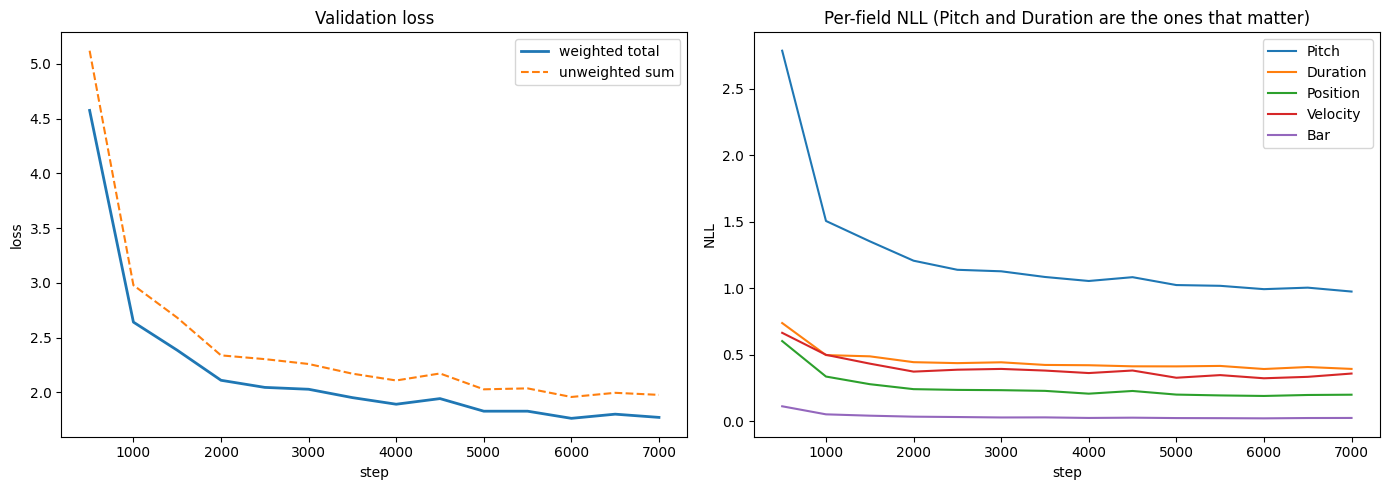

In [16]:
import matplotlib.pyplot as plt

if history:
    x = [h["step"] for h in history]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(x, [h["val_loss"] for h in history], label="weighted total", lw=2)
    a1.plot(x, [h["val_loss_unweighted"] for h in history], "--", label="unweighted sum")
    a1.set_xlabel("step"); a1.set_ylabel("loss"); a1.legend(); a1.set_title("Validation loss")

    for name in ["Pitch", "Duration", "Position", "Velocity", "Bar"]:
        if name in history[0]:
            a2.plot(x, [h[name] for h in history], label=name)
    a2.set_xlabel("step"); a2.set_ylabel("NLL"); a2.legend()
    a2.set_title("Per-field NLL (Pitch and Duration are the ones that matter)")
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

## Generation: continuing a prompt

Two things below have no equivalent in the jam model, and both exist because `Bar` is an absolute index rather than a delimiter.

**Sliding context with bar re-basing.** The model was trained on windows that always start at `Bar_0` — that was the whole point of re-basing in the dataset builder. So at generation time the context fed to the model must be re-based the same way, every step, or the model drifts into a bar-number region it barely saw in training. The absolute bar of each generated note is tracked separately and restored before decoding to MIDI.

**Hard constraints on the time fields.** Music has rules that are cheaper to enforce than to learn: bar indices never go backwards, and within a bar neither does position. Masking these before sampling costs nothing and removes the failure mode where one unlucky sample throws the rest of the piece into temporal chaos. This is the second reason `Bar` and `Position` are first in the head order — by the time pitch is sampled, the note's position in time is already fixed and legal.

Temperatures are per field. Keep the structural fields cold (`Bar`, `Position`, `Program`, `TimeSig` near 0.7) and let `Pitch`/`Velocity` run warmer. Sampling `Program` hot in `multi_instrument` mode makes the arrangement flicker between instruments note by note.

In [17]:
from miditok import TokSequence
from symusic import Score

MAX_BAR = VOCAB_SIZES[BAR_IDX] - BAR0_ID - 1     # highest representable bar index

TEMPS_BY_NAME = {"Pitch": 1.0, "Duration": 0.9, "Velocity": 1.0, "Position": 0.8,
                 "Bar": 0.7, "Program": 0.6, "Tempo": 0.7, "TimeSig": 0.5}
TOP_P_BY_NAME = {"Pitch": 0.95, "Duration": 0.95, "Velocity": 0.98, "Position": 0.9,
                 "Bar": 0.9, "Program": 0.9, "Tempo": 0.9, "TimeSig": 0.9}
TEMPS = [TEMPS_BY_NAME.get(IDX2NAME.get(i, ""), 1.0) for i in range(NUM_FIELDS)]
TOP_P = [TOP_P_BY_NAME.get(IDX2NAME.get(i, ""), 0.95) for i in range(NUM_FIELDS)]


def _rebase(ctx):
    """Shift a context window so its first note sits at Bar_0. Returns (ctx, shift)."""
    shift = int(ctx[0, BAR_IDX].item()) - BAR0_ID
    if shift:
        ctx = ctx.clone()
        ctx[:, BAR_IDX] -= shift
    return ctx, shift


def build_allowed_masks(device):
    """Ban PAD/BOS/EOS/MASK in every field. These ids are in every vocabulary and
    nothing stops the model drawing one; a PAD in the Program field yields a stream
    miditok cannot decode at all. Cheap to forbid, expensive to discover."""
    masks = []
    for f, voc in enumerate(VOCABS):
        m = torch.ones(1, VOCAB_SIZES[f], dtype=torch.bool, device=device)
        for tok in getattr(tokenizer, "special_tokens", []):
            if tok in voc:
                m[0, voc[tok]] = False
        masks.append(m)
    return masks


ALLOWED = build_allowed_masks(device)


def make_constraint_fn(last_bar_local, last_pos):
    """Bar may hold or advance by at most 2 (a skipped bar is a rest, not an error);
    Position may not move backwards inside the same bar. Written for batch size 1."""
    def fn(f, partial):
        base = ALLOWED[f]
        if f == BAR_IDX:
            m = torch.zeros_like(base)
            lo = BAR0_ID + last_bar_local
            m[0, lo:min(lo + 3, VOCAB_SIZES[BAR_IDX])] = True
            return base & m
        if f == POS_IDX and int(partial[0, BAR_IDX].item()) - BAR0_ID == last_bar_local:
            m = base.clone()
            m[0, :last_pos] = False
            return m if m.any() else base
        return base
    return fn


@torch.no_grad()
def generate(model, prompt, num_notes=1024, ctx_len=None, verbose=True):
    """prompt: (n, num_fields) int array with ABSOLUTE bar ids. Returns the
    prompt plus num_notes generated notes, still with absolute bar ids."""
    net = unwrap(model).eval()
    ctx_len = ctx_len or (SEQ_LEN + 1)
    gen = torch.as_tensor(np.asarray(prompt), dtype=torch.long, device=device)
    t0 = time.time()

    for step in range(num_notes):
        ctx, shift = _rebase(gen[-ctx_len:])
        if int(ctx[:, BAR_IDX].max().item()) - BAR0_ID > MAX_BAR:
            print("context spans more bars than the Bar vocabulary; stopping")
            break
        last_bar_local = int(ctx[-1, BAR_IDX].item()) - BAR0_ID
        last_pos = int(ctx[-1, POS_IDX].item())
        fn = make_constraint_fn(last_bar_local, last_pos)
        nxt = net.sample_next(ctx.unsqueeze(0), TEMPS, TOP_P, constraint_fn=fn)[0].clone()
        nxt[BAR_IDX] += shift                            # local -> absolute
        if int(nxt[BAR_IDX].item()) - BAR0_ID > MAX_BAR:
            print(f"reached the last representable bar at note {step}"); break
        gen = torch.cat([gen, nxt.unsqueeze(0)], dim=0)

        if verbose and (step + 1) % 128 == 0:
            bars = int(gen[-1, BAR_IDX].item()) - BAR0_ID
            print(f"  {step+1}/{num_notes} notes | bar {bars} | "
                  f"{(step+1)/(time.time()-t0):.1f} notes/s")
    return gen.cpu().numpy()


def to_midi(arr, path):
    ts = TokSequence(ids=[[int(v) for v in row] for row in arr], are_ids_encoded=False)
    try:
        score = tokenizer.decode(ts)
    except Exception:
        score = tokenizer.decode([ts])
    score.dump_midi(str(path))
    n = sum(len(t.notes) for t in score.tracks)
    print(f"wrote {path} | {n} notes / {len(score.tracks)} tracks")
    return score


def prompt_from_midi(path, max_notes=256, track=0):
    """Tokenize a MIDI, take one track, re-base to Bar_0, keep the last max_notes."""
    sc = Score(str(path))
    one = sc.copy(); one.tracks = [sc.tracks[track]]
    res = tokenizer.encode(one)
    seq = res[0] if isinstance(res, list) else res
    a = np.asarray(seq.ids, dtype=np.int64)
    a = a[-max_notes:]
    a[:, BAR_IDX] -= (a[0, BAR_IDX] - BAR0_ID)
    return a

In [18]:
# ---- Run a continuation ----
# Load the best checkpoint, prompt with a MIDI, continue for 1024 notes.
_ck = torch.load(CKPT_BEST, map_location=device, weights_only=False)
unwrap(model).load_state_dict(_ck["model"])
print(f"loaded best checkpoint from step {_ck['global_step']} "
      f"(val {_ck['best_val_loss']:.4f})")

PROMPT_MIDI = None      # e.g. "/kaggle/input/.../prompt.mid"

if PROMPT_MIDI:
    prompt = prompt_from_midi(PROMPT_MIDI, max_notes=256)
else:
    # No prompt: start from a validation window so generation has real context.
    _i = int(val_starts[0].item())
    prompt = val_flat[_i:_i + 256].long().numpy()
    prompt[:, BAR_IDX] -= (prompt[0, BAR_IDX] - BAR0_ID)

print("prompt:", prompt.shape[0], "notes | bars",
      int(prompt[0, BAR_IDX]) - BAR0_ID, "..", int(prompt[-1, BAR_IDX]) - BAR0_ID)

out = generate(model, prompt, num_notes=1024)
print(f"\ntotal {len(out)} notes, spanning "
      f"{int(out[-1, BAR_IDX]) - BAR0_ID + 1} bars")
to_midi(out, "/kaggle/working/continuation.mid")
to_midi(out[:len(prompt)], "/kaggle/working/continuation_prompt_only.mid")

loaded best checkpoint from step 6000 (val 1.7614)
prompt: 256 notes | bars 0 .. 0
  128/1024 notes | bar 0 | 53.2 notes/s
  256/1024 notes | bar 1 | 53.1 notes/s
  384/1024 notes | bar 1 | 51.3 notes/s
  512/1024 notes | bar 1 | 46.9 notes/s
  640/1024 notes | bar 1 | 43.0 notes/s
  768/1024 notes | bar 1 | 39.4 notes/s
  896/1024 notes | bar 1 | 36.7 notes/s
  1024/1024 notes | bar 2 | 34.8 notes/s

total 1280 notes, spanning 3 bars
wrote /kaggle/working/continuation.mid | 1280 notes / 1 tracks
wrote /kaggle/working/continuation_prompt_only.mid | 256 notes / 1 tracks


Score(ttype=Tick, tpq=16, begin=0, end=60, tracks=1, notes=256, time_sig=1, key_sig=0, markers=0)

## What to change next, in order

1. **`STRIDE` down to 128.** Free in this data layout, and 4× the windows means much less repetition across the run. Do this before anything else if `passes_over_budget` in the manifest came out below ~1.
2. **`SEQ_LEN` up to 2047** with `BATCH_SIZE=8`, `ACCUM_STEPS=16`, `GRAD_CHECKPOINT=True`. This is the change that most directly targets long-form structure. Watch that `frac_ge_min` in the manifest — sequences shorter than 2048 notes are silently dropped, and the effective corpus can shrink a lot.
3. **`multi_instrument` mode** in the dataset builder if arrangement rather than single-line continuation is the goal. The `Program` head and its loss weight start earning their keep, and `Program` temperature at generation matters a great deal.
4. **Only then, `d_model=768`, `n_layers=16`.** ~110M params, which needs `GRAD_CHECKPOINT` and a smaller batch on T4s, and pushes the token budget well past what 150k files supply.

One diagnostic worth running before any of this: generate 2000 notes and look at whether bar 40 sounds related to bar 8. Per-field NLL will not tell you — it is dominated by local prediction, and a model that has learned nothing about song structure can still post an excellent `Pitch` loss. Structure only shows up in listening, or in explicit self-similarity measures over the generated bar matrix.